# Notebook 2 — FakeHealth · Baseline Classifier
## Pipeline TF-IDF → Classifieurs ML · Table 1 du rapport

**Projet :** A Multi-Source Benchmark for CVD Health Misinformation Detection  
**Dataset :** FakeHealth HealthStory — Dai, Sun & Wang (ICWSM 2020)  
**Prérequis :** Generate the healthStory.csv

---
### What does this notebook do ?
1. Load `HealthStory_clean.csv`
2. Prepare TF-IDF
3. Train two classifers baseline :
   - Logistic regression
   - Naive Bayes 
4. Evaluaion with crossed validation 5-fold 
5. Calculate the accuracy, precision, recall, F1 (macro + par classe)
6. Analyse  errors (confused martrix, examples of errors)
7. Analyse the importance of features
8. produce **Table 1** 
9. Save all trained for comparaison with LLMs


---
## Section 1 — Installation & imports

In [1]:
# Décommentez si besoin :
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(' Imports OK')

 Imports OK


---
## Section 2 — Data Loading
Load the CSV by running NB1...


In [2]:

candidate_paths = [
    '../dataset/healthstory_baseline_ready.csv',
    'HealthStory_clean.csv',
]
# ─────────────────────────────────────────────────────────────────────

CSV_PATH = next((p for p in candidate_paths if os.path.exists(p)), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        'Aucun fichier CSV trouvé parmi:\n'
        + '\n'.join(candidate_paths)
    )

df = pd.read_csv(CSV_PATH, encoding='utf-8')
print(f'All data loaded: {len(df)} articles')
print(f'CSV used: {CSV_PATH}')


All data loaded: 1638 articles
CSV used: ../dataset/healthstory_baseline_ready.csv


In [3]:
# VCheck and execute
print('── Raised values ──')
print(df.isnull().sum().to_string())
print()

# SRemove all lines without body and title
n_before = len(df)
df = df.dropna(subset=['label'])

# Colone texte : combine title + body
has_body  = 'body'  in df.columns
has_title = 'title' in df.columns

if has_body and has_title:
    df['text'] = df['title'].fillna('') + ' ' + df['body'].fillna('')
    print(' Colone text = has title + body')
elif has_body:
    df['text'] = df['body'].fillna('')
    print(' Colonne text = has only body')
elif has_title:
    df['text'] = df['title'].fillna('')
    print('Colonne text = has title only  (missing body )')
else:
    raise ValueError('No "body" no "title" find in this path.')

df = df[df['text'].str.strip().astype(bool)]  

print(f'   Articles conserved : {len(df)} (removed : {n_before - len(df)})')

X = df['text'].values
y = df['label'].values

print(f'   Fake (0) : {(y==0).sum()} | Real (1) : {(y==1).sum()}')

── Raised values ──
file_id          0
title           34
text            24
label            0
label_name       0
rating_float     0
dataset          0

Colonne text = has title only  (missing body )
   Articles conserved : 1604 (removed : 34)
   Fake (0) : 450 | Real (1) : 1154


---
## Section 3 —  Train / Test
Use stratified split 80/20

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y       # ← important : maintain proportion fake/real
)

print('── Split Train / Test ──')
print(f'  Train : {len(X_train)} articles')
print(f'    Fake : {(y_train==0).sum()} | Real : {(y_train==1).sum()}')
print(f'  Test  : {len(X_test)} articles')
print(f'    Fake : {(y_test==0).sum()} | Real : {(y_test==1).sum()}')

── Split Train / Test ──
  Train : 1283 articles
    Fake : 360 | Real : 923
  Test  : 321 articles
    Fake : 90 | Real : 231


---
## Section 4 — Construction des pipelines TF-IDF

### Paramètres TF-IDF retenus
| Paramètre | Valeur | Justification |
|---|---|---|
| `ngram_range` | (1, 2) | Capture les expressions bi-mot ('heart disease', 'clinical trial') |
| `max_features` | 10 000 | Limite le bruit tout en couvrant le vocabulaire médical |
| `sublinear_tf` | True | Compresse les fréquences élevées (log(1+tf)) — standard NLP |
| `stop_words` | english | Retire les mots vides non informatifs |
| `min_df` | 2 | Ignore les termes n'apparaissant qu'une seule fois |
| `max_df` | 0.95 | Ignore les termes présents dans >95% des docs |


In [5]:
# Vectorizer common to both models
TFIDF_PARAMS = dict(
    ngram_range  = (1, 2),
    max_features = 10_000,
    sublinear_tf = True,
    stop_words   = 'english',
    min_df       = 2,
    max_df       = 0.95
)

# ── Pipeline 1 :  Logistic Regression ───────────────────────────────────
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',  LogisticRegression(
        C           = 1.0,       # regularization L2 standard
        max_iter    = 1000,
        random_state= RANDOM_STATE,
        class_weight= 'balanced' 
    ))
])

# ── Pipeline 2 : Naive Bayes Multinomial ─────────────────────────────────
pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',  MultinomialNB(alpha=0.5))  # α=0.5 : lissage de Lidstone
])

# ── Pipeline 3 : LinearSVC
pipe_svm = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',  LinearSVC(
        C           = 1.0,
        max_iter    = 2000,
        random_state= RANDOM_STATE,
        class_weight= 'balanced'
    ))
])

models = {
    'Logistic Regression': pipe_lr,
    'Naive Bayes':         pipe_nb,
    'LinearSVC':           pipe_svm,
}


for name, pipe in models.items():
    print(f'   • {name}')

   • Logistic Regression
   • Naive Bayes
   • LinearSVC


---
## Section 5 — crossed validation


In [6]:
from sklearn.model_selection import cross_validate

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}

SCORING = {
    'accuracy' : 'accuracy',
    'f1_macro' : 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro'   : 'recall_macro',
    'f1_fake'  : 'f1_score',  
}


for name, pipe in models.items():
    cv = cross_validate(
        pipe, X, y,
        cv      = SKF,
        scoring = {
            'accuracy'        : 'accuracy',
            'f1_macro'        : 'f1_macro',
            'precision_macro' : 'precision_macro',
            'recall_macro'    : 'recall_macro',
        },
        return_train_score = False,
        n_jobs = -1
    )
    cv_results[name] = cv

    print(f'── {name} ──')
    print(f'  Accuracy  : {cv["test_accuracy"].mean():.4f} ± {cv["test_accuracy"].std():.4f}')
    print(f'  F1 macro  : {cv["test_f1_macro"].mean():.4f} ± {cv["test_f1_macro"].std():.4f}')
    print(f'  Precision : {cv["test_precision_macro"].mean():.4f} ± {cv["test_precision_macro"].std():.4f}')
    print(f'  Recall    : {cv["test_recall_macro"].mean():.4f} ± {cv["test_recall_macro"].std():.4f}')
    print()

── Logistic Regression ──
  Accuracy  : 0.5779 ± 0.0138
  F1 macro  : 0.5107 ± 0.0236
  Precision : 0.5131 ± 0.0241
  Recall    : 0.5155 ± 0.0282

── Naive Bayes ──
  Accuracy  : 0.7014 ± 0.0137
  F1 macro  : 0.4704 ± 0.0270
  Precision : 0.5330 ± 0.0704
  Recall    : 0.5098 ± 0.0177

── LinearSVC ──
  Accuracy  : 0.5804 ± 0.0197
  F1 macro  : 0.5094 ± 0.0264
  Precision : 0.5109 ± 0.0258
  Recall    : 0.5125 ± 0.0281



---
## Section 6 —  final training and evaluating the test set
Training the 80% of the train set and evaluate on the 20% of the reseved set

In [7]:
test_results = {}

for name, pipe in models.items():
    # Training the train set
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    test_results[name] = {
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_test, y_pred),
        'prec_macro': precision_score(y_test, y_pred, average='macro'),
        'rec_macro' : recall_score(y_test, y_pred, average='macro'),
        'f1_macro'  : f1_score(y_test, y_pred, average='macro'),
        'f1_fake'   : f1_score(y_test, y_pred, pos_label=0),
        'f1_real'   : f1_score(y_test, y_pred, pos_label=1),
    }

    print(f'── {name} — Test Set ──')
    print(classification_report(y_test, y_pred, target_names=['Fake','Real']))


── Logistic Regression — Test Set ──
              precision    recall  f1-score   support

        Fake       0.34      0.42      0.38        90
        Real       0.75      0.68      0.71       231

    accuracy                           0.61       321
   macro avg       0.55      0.55      0.54       321
weighted avg       0.64      0.61      0.62       321

── Naive Bayes — Test Set ──
              precision    recall  f1-score   support

        Fake       0.45      0.11      0.18        90
        Real       0.73      0.95      0.83       231

    accuracy                           0.71       321
   macro avg       0.59      0.53      0.50       321
weighted avg       0.65      0.71      0.64       321

── LinearSVC — Test Set ──
              precision    recall  f1-score   support

        Fake       0.36      0.44      0.40        90
        Real       0.76      0.70      0.73       231

    accuracy                           0.63       321
   macro avg       0.56      0.57  

---
## Section 7 — confused matrix

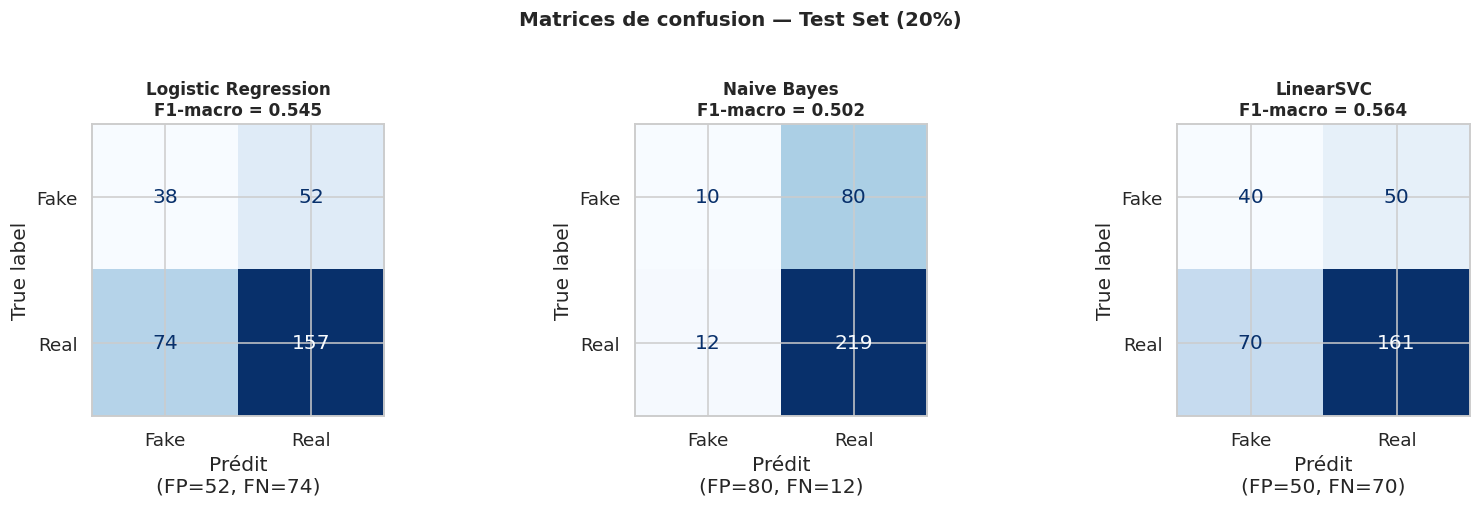

 Sauvegardé : fig6_confusion_matrices.png


In [8]:
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Fake', 'Real'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1-macro = {res["f1_macro"]:.3f}',
                 fontsize=11, fontweight='bold')

    # Annotations : FP/FN
    fn = cm[1][0]  # real fake predicts real
    fp = cm[0][1]  # real real predicts fake
    ax.set_xlabel(f'Prédit\n(FP={fp}, FN={fn})')

plt.suptitle('Confused matrix — Test Set (20%)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', bbox_inches='tight', dpi=130)
plt.show()
print(' saved : fig6_confusion_matrices.png')

---
## Section 8 — Features most discriminants
Pour la Régression Logistique,  coefficients indicates wchich word move on Fake ou Real.

Target terms matched in TF-IDF vocabulary:
  Found: 33 / 88

Top discriminant target terms (all directions):


,group,term,matched_features,n_matched_features,coef_mean,coef_abs_mean,direction
0,medical_general_terms,electronic health records,health,1,-1.075032,1.075032,Fake
1,diabetes_symptoms,slow wound healing,slow,1,-0.851695,0.851695,Fake
2,cardiovascular_diseases,stroke,stroke,1,0.731580,0.731580,Real
3,diabetes_symptoms,weight loss,weight loss,1,0.705714,0.705714,Real
4,diabetes_treatments,insulin,insulin,1,-0.680907,0.680907,Fake
5,diabetes_treatments,glucose-lowering drugs,drugs,1,0.677364,0.677364,Real
6,medical_general_terms,hospital,hospital,1,-0.503346,0.503346,Fake
7,cardiovascular_treatments,stent,stent,1,-0.429371,0.429371,Fake
8,diabetes_complications,diabetic foot ulcer,diabetic,1,-0.368294,0.368294,Fake
9,cardiovascular_diseases,coronary artery disease,disease,1,-0.355523,0.355523,Fake


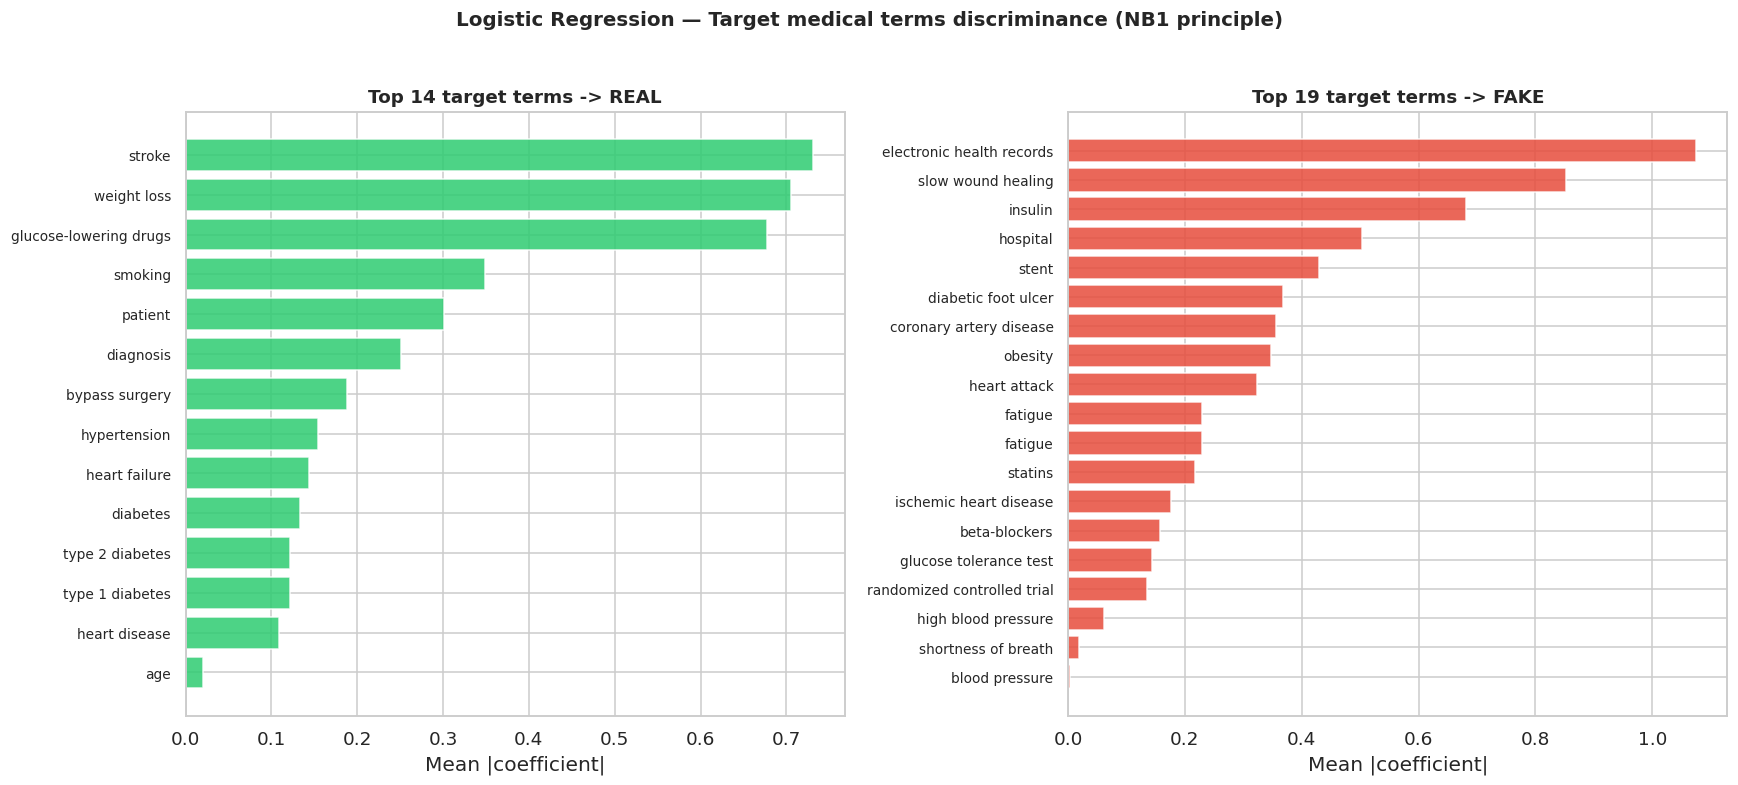

Sauvegarde: fig7_feature_importance_target_terms.png


In [12]:
import re

# Extract most important features (Logistic Regression)
lr_pipe = models['Logistic Regression']
vectorizer = lr_pipe.named_steps['tfidf']
classifier = lr_pipe.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()
coefs = classifier.coef_[0]  # positif -> Real, negatif -> Fake
coef_map = pd.Series(coefs, index=feature_names)

# like NB1
cardiovascular_diseases = [
    "cardiovascular disease", "heart disease", "coronary artery disease",
    "ischemic heart disease", "myocardial infarction", "heart attack",
    "stroke", "ischemic stroke", "hypertension", "high blood pressure",
    "heart failure", "arrhythmia"
]

cardiovascular_symptoms = [
    "chest pain", "angina", "shortness of breath", "dyspnea", "palpitations",
    "fatigue", "dizziness", "syncope", "edema"
]

cardiovascular_risk_factors = [
    "smoking", "tobacco use", "obesity", "bmi", "high cholesterol", "ldl", "hdl",
    "diabetes", "sedentary lifestyle", "family history", "age"
]

cardiovascular_treatments = [
    "statins", "beta-blockers", "antihypertensive drugs", "aspirin therapy",
    "angioplasty", "stent", "bypass surgery"
]

cardiovascular_tests = [
    "ecg", "electrocardiogram", "blood pressure", "cholesterol levels",
    "troponin", "echocardiogram"
]

diabetes_types = [
    "type 1 diabetes", "type 2 diabetes", "gestational diabetes", "prediabetes"
]

diabetes_symptoms = [
    "frequent urination", "polyuria", "excessive thirst", "polydipsia",
    "fatigue", "weight loss", "blurred vision", "slow wound healing"
]

diabetes_treatments = [
    "insulin", "metformin", "glucose-lowering drugs", "glp-1 agonists",
    "lifestyle intervention", "diet control"
]

diabetes_biomarkers = [
    "blood glucose", "fasting glucose", "hba1c", "insulin level", "glucose tolerance test"
]

diabetes_complications = [
    "neuropathy", "nephropathy", "retinopathy", "cardiovascular disease", "diabetic foot ulcer"
]

medical_general_terms = [
    "risk factor", "prevalence", "incidence", "mortality", "clinical trial",
    "diagnosis", "treatment outcome", "patient", "hospital", "clinical study",
    "randomized controlled trial", "medical record", "electronic health records",
    "clinical notes", "medical report"
]

term_groups = {
    "cardiovascular_diseases": cardiovascular_diseases,
    "cardiovascular_symptoms": cardiovascular_symptoms,
    "cardiovascular_risk_factors": cardiovascular_risk_factors,
    "cardiovascular_treatments": cardiovascular_treatments,
    "cardiovascular_tests": cardiovascular_tests,
    "diabetes_types": diabetes_types,
    "diabetes_symptoms": diabetes_symptoms,
    "diabetes_treatments": diabetes_treatments,
    "diabetes_biomarkers": diabetes_biomarkers,
    "diabetes_complications": diabetes_complications,
    "medical_general_terms": medical_general_terms,
}

def _normalize_term(term):
    return re.sub(r"\s+", " ", str(term).strip().lower())

def _extract_matching_ngrams(term):
    """
    TF-IDF: ngram_range=(1,2).
    - if term 1-2 words: try exact match
    - else: goes on the unigrams+bigrams content 
    """
    t = _normalize_term(term)
    tokens = re.findall(r"[a-z0-9]+", t)
    if not tokens:
        return []

    if len(tokens) <= 2:
        return [" ".join(tokens)]

    cands = [" ".join(tokens[i:i+2]) for i in range(len(tokens) - 1)]
    cands.extend(tokens)

    #keep order
    seen = set()
    uniq = []
    for c in cands:
        if c not in seen:
            uniq.append(c)
            seen.add(c)
    return uniq

def discriminant_target_terms(term_groups, coef_map):
    rows = []
    for group_name, terms in term_groups.items():
        for term in terms:
            candidates = _extract_matching_ngrams(term)
            matched = [c for c in candidates if c in coef_map.index]

            if not matched:
                rows.append({
                    'group': group_name,
                    'term': term,
                    'matched_features': '',
                    'n_matched_features': 0,
                    'coef_mean': np.nan,
                    'coef_abs_mean': np.nan,
                    'direction': 'not_found'
                })
                continue

            vals = coef_map.loc[matched].astype(float).values
            coef_mean = float(vals.mean())
            coef_abs_mean = float(np.abs(vals).mean())

            if coef_mean > 0:
                direction = 'Real'
            elif coef_mean < 0:
                direction = 'Fake'
            else:
                direction = 'Neutral'

            rows.append({
                'group': group_name,
                'term': term,
                'matched_features': ', '.join(matched),
                'n_matched_features': len(matched),
                'coef_mean': coef_mean,
                'coef_abs_mean': coef_abs_mean,
                'direction': direction
            })

    out = pd.DataFrame(rows)
    return out

target_df = discriminant_target_terms(term_groups, coef_map)
target_found = target_df[target_df['n_matched_features'] > 0].copy()

print('Target terms matched in TF-IDF vocabulary:')
print(f"  Found: {len(target_found)} / {len(target_df)}")
print()

if target_found.empty:
    print('No target terms from term_groups were found in the trained TF-IDF features.')
else:
    target_found = target_found.sort_values('coef_abs_mean', ascending=False).reset_index(drop=True)
    print('Top discriminant target terms (all directions):')
    display(target_found.head(30))

    TOP_N = 20
    feat_real = target_found[target_found['coef_mean'] > 0].head(TOP_N).copy()
    feat_fake = target_found[target_found['coef_mean'] < 0].head(TOP_N).copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

    # Terms -> Real
    ax = axes[0]
    if len(feat_real) > 0:
        ax.barh(range(len(feat_real)), feat_real['coef_abs_mean'], color='#2ecc71', alpha=0.85)
        ax.set_yticks(range(len(feat_real)))
        ax.set_yticklabels(feat_real['term'], fontsize=9)
    ax.set_title(f'Top {min(TOP_N, len(feat_real))} target terms -> REAL', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |coefficient|')
    ax.invert_yaxis()

    # Terms -> Fake
    ax = axes[1]
    if len(feat_fake) > 0:
        ax.barh(range(len(feat_fake)), feat_fake['coef_abs_mean'], color='#e74c3c', alpha=0.85)
        ax.set_yticks(range(len(feat_fake)))
        ax.set_yticklabels(feat_fake['term'], fontsize=9)
    ax.set_title(f'Top {min(TOP_N, len(feat_fake))} target terms -> FAKE', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |coefficient|')
    ax.invert_yaxis()

    plt.suptitle('Logistic Regression — Target medical terms discriminance (NB1 principle)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('fig7_feature_importance_target_terms.png', bbox_inches='tight', dpi=130)
    plt.show()
    print('Sauvegarde: fig7_feature_importance_target_terms.png')

---
## Section 9 — Analyse des erreurs
Quels articles sont mal classifiés ? Y a-t-il des patterns dans les erreurs ?

In [13]:
# On utilise LR comme modèle principal pour l'analyse d'erreurs
y_pred_lr = test_results['Logistic Regression']['y_pred']

# Reconstruction robuste des index du test set (même paramètres que le split principal)
all_indices = np.arange(len(df))
_, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df['label']
)

test_df = df.iloc[test_indices].copy().reset_index(drop=True)
test_df['y_true'] = np.asarray(y_test)
test_df['y_pred'] = np.asarray(y_pred_lr)
test_df['correct'] = (test_df['y_true'] == test_df['y_pred'])

errors = test_df[~test_df['correct']]

print(f'Erreurs totales : {len(errors)} / {len(test_df)} ({100*len(errors)/len(test_df):.1f}%)')
print()

# Faux positifs : articles REAL classifies FAKE
fp = errors[(errors['y_true'] == 1) & (errors['y_pred'] == 0)]
# Faux negatifs : articles FAKE classes REAL
fn = errors[(errors['y_true'] == 0) & (errors['y_pred'] == 1)]

print(f'Faux positifs (Real -> Fake) : {len(fp)}')
print(f'Faux negatifs (Fake -> Real) : {len(fn)}')
print()

Erreurs totales : 126 / 321 (39.3%)

Faux positifs (Real -> Fake) : 74
Faux negatifs (Fake -> Real) : 52

Attention: les faux negatifs sont critiques (misinformation non detectee).


In [14]:
# Exemples de faux négatifs (misinformations non détectées)
print('── Exemples de FAUX NÉGATIFS (Fake → prédit Real) ──')
print('   Ces articles contiennent de la désinformation mais ressemblent à du vrai')
print()

text_col = 'text' if 'text' in fn.columns else fn.columns[0]
for i, (_, row) in enumerate(fn.head(3).iterrows()):
    txt = str(row.get('text', row.get('title', 'N/A')))[:300]
    rating = row.get('rating_float', 'N/A')
    print(f'  [{i+1}] rating={rating}')
    print(f'       {txt}...')
    print()

print('── Exemples de FAUX POSITIFS (Real → prédit Fake) ──')
print('   Ces articles sont vrais mais ont des patterns linguistiques ambigus')
print()
for i, (_, row) in enumerate(fp.head(3).iterrows()):
    txt = str(row.get('text', row.get('title', 'N/A')))[:300]
    rating = row.get('rating_float', 'N/A')
    print(f'  [{i+1}] rating={rating}')
    print(f'       {txt}...')
    print()

── Exemples de FAUX NÉGATIFS (Fake → prédit Real) ──
   Ces articles contiennent de la désinformation mais ressemblent à du vrai

  [1] rating=2
       Less Invasive Biopsies Gain Favor...

  [2] rating=2
       Urine test for prostate cancer may be better than blood test...

  [3] rating=2
       Study Suggests Osteoporosis Drug Might Treat Loss of Bone in Jaw...

── Exemples de FAUX POSITIFS (Real → prédit Fake) ──
   Ces articles sont vrais mais ont des patterns linguistiques ambigus

  [1] rating=3
       Blood injections may help chronic "tennis elbow"...

  [2] rating=3
       Outlook, Office, Skype, Bing, Breaking News, and Latest Videos...

  [3] rating=4
       Ovarian Tissue Transplant Can Help Some Women Have Kids After Cancer Treatment...



---
## Section 10 — Comparaison des modèles (visualisation)
Graphique comparatif des métriques pour les 3 modèles.

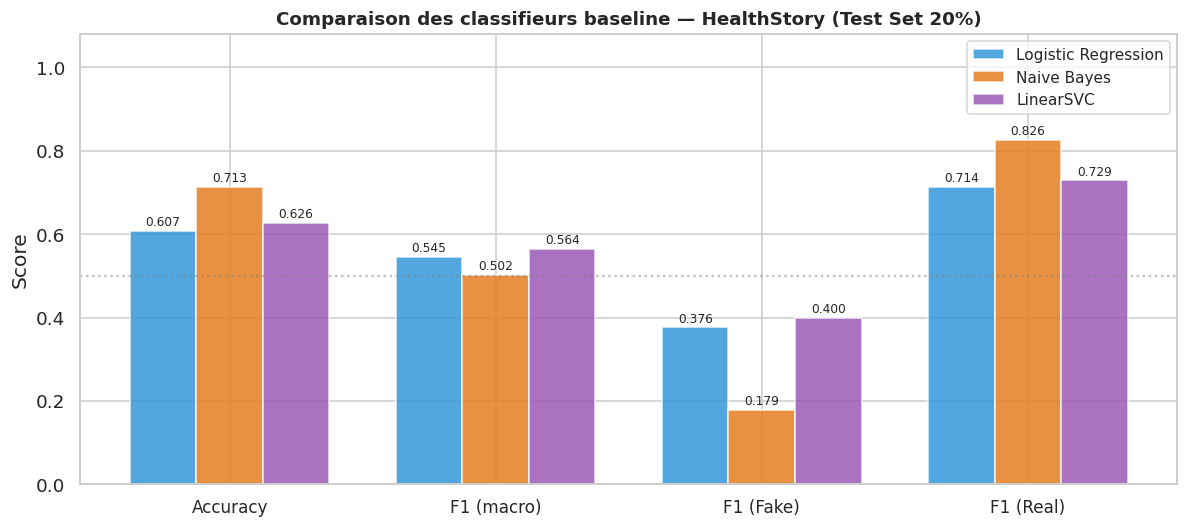

 Sauvegardé : fig9_model_comparison.png


In [15]:
# Données de comparaison
metrics = ['accuracy', 'f1_macro', 'f1_fake', 'f1_real']
metric_labels = ['Accuracy', 'F1 (macro)', 'F1 (Fake)', 'F1 (Real)']
model_names = list(test_results.keys())

x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#e67e22', '#9b59b6']

fig, ax = plt.subplots(figsize=(11, 5))

for i, (name, res) in enumerate(test_results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=colors[i], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Compare classification baseline — HealthStory (Test Set 20%)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance level')

plt.tight_layout()
plt.savefig('fig9_model_comparison.png', bbox_inches='tight', dpi=130)
plt.show()
print(' saved : fig9_model_comparison.png')

---
## Section 11 — TABLE 1 (final)


In [16]:
print('=' * 80)
print('TABLE 1 — Baseline Classifier Performance — HealthStory (FakeHealth)')
print('Features : TF-IDF unigrammes + bigrammes (max 10 000 features)')
print('Split    : 80% train / 20% test (stratifié) | Validation : 5-fold CV')
print('=' * 80)

# Header
header = f'{"Modèle":<30} {"Acc":>7} {"Prec":>7} {"Recall":>7} {"F1-mac":>7} {"F1-Fake":>8} {"F1-Real":>8} {"CV F1±σ":>13}'
print(header)
print('-' * 80)

for name, res in test_results.items():
    cv   = cv_results[name]
    cv_f1_mean = cv['test_f1_macro'].mean()
    cv_f1_std  = cv['test_f1_macro'].std()
    row = (
        f'{name:<30} '
        f'{res["accuracy"]:>7.3f} '
        f'{res["prec_macro"]:>7.3f} '
        f'{res["rec_macro"]:>7.3f} '
        f'{res["f1_macro"]:>7.3f} '
        f'{res["f1_fake"]:>8.3f} '
        f'{res["f1_real"]:>8.3f} '
        f'{cv_f1_mean:>6.3f}±{cv_f1_std:.3f}'
    )
    print(row)

print('=' * 80)
print()

TABLE 1 — Baseline Classifier Performance — HealthStory (FakeHealth)
Features : TF-IDF unigrammes + bigrammes (max 10 000 features)
Split    : 80% train / 20% test (stratifié) | Validation : 5-fold CV
Modèle                             Acc    Prec  Recall  F1-mac  F1-Fake  F1-Real       CV F1±σ
--------------------------------------------------------------------------------
Logistic Regression              0.607   0.545   0.551   0.545    0.376    0.714  0.511±0.024
Naive Bayes                      0.713   0.593   0.530   0.502    0.179    0.826  0.470±0.027
LinearSVC                        0.626   0.563   0.571   0.564    0.400    0.729  0.509±0.026

Notes :
  • F1-macro = métrique principale (déséquilibre léger 55/45)
  • F1-Fake  = capacité à détecter les misinformations (critère le plus important)
  • Ces valeurs sont le plancher attendu pour les LLMs zero-shot (Phase 2)
  • LLMs fine-tunés (BERT/RoBERTa) devraient atteindre F1 ≈ 0.85–0.92


Sauvegardé : Table1_baseline_results.csv

              Model  Accuracy  Precision  Recall  F1_macro  F1_Fake  F1_Real  CV_F1_mean  CV_F1_std                  Features
Logistic Regression     0.607      0.545   0.551     0.545    0.376    0.714       0.511      0.024 TF-IDF (1-2gram, max=10k)
        Naive Bayes     0.713      0.593   0.530     0.502    0.179    0.826       0.470      0.027 TF-IDF (1-2gram, max=10k)
          LinearSVC     0.626      0.563   0.571     0.564    0.400    0.729       0.509      0.026 TF-IDF (1-2gram, max=10k)


 Logistic Regression → models/logistic_regression_healthstory.pkl
 Naive Bayes → models/naive_bayes_healthstory.pkl
 LinearSVC → models/linearsvc_healthstory.pkl
 Test set → healthstory_test_set.csv (321 articles)

 Prêt pour la Phase 2 : évaluation des LLMs sur le même test set
